<a href="https://colab.research.google.com/github/PandeyChhaya/6CS012-AI-ML/blob/main/Worksheet%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing and choosing file from upload


In [3]:
from google.colab import files
file = files.upload()

Saving FruitinAmazon.zip to FruitinAmazon (1).zip


Unzipping the zip file


In [4]:
import zipfile, os

with zipfile.ZipFile("FruitinAmazon.zip", "r") as z:
    z.extractall("FruitinAmazon")

print("Done! Contents:")
for item in os.listdir("FruitinAmazon"):
    print(" ", item)

Done! Contents:
  FruitinAmazon


Checking the folder structure once again in google colab


In [5]:
for root, dirs, files in os.walk("FruitinAmazon"):
    level = root.replace("FruitinAmazon", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:
        print(f"{indent}  ({len(files)} images)")

FruitinAmazon/
  FruitinAmazon/
    test/
      (0 images)
      guarana/
      acai/
      tucuma/
      pupunha/
      cupuacu/
      graviola/
    train/
      (0 images)
      guarana/
      acai/
      tucuma/
      pupunha/
      cupuacu/
      graviola/


Task 1:
 Data Understanding and Visualization:

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


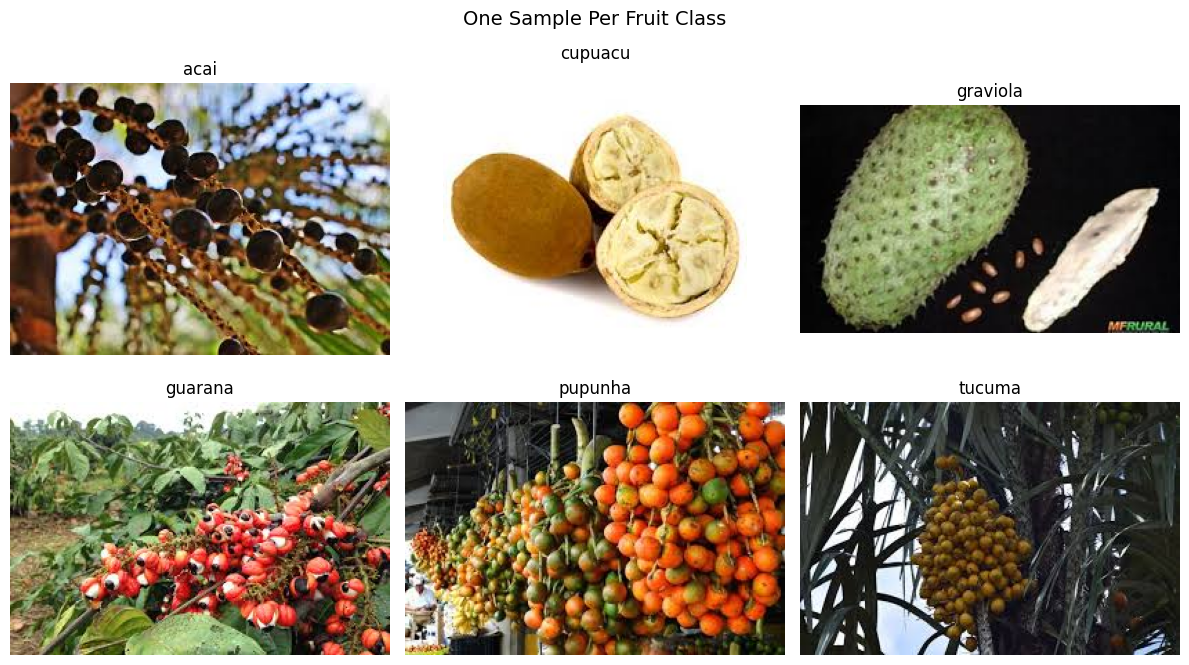

No corrupted images found.


In [6]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "FruitinAmazon/FruitinAmazon/train"
test_dir  = "FruitinAmazon/FruitinAmazon/test"

class_dirs = sorted(os.listdir(train_dir))
print("Classes:", class_dirs)

# Visualize one image per class
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, cls in enumerate(class_dirs):
    cls_path = os.path.join(train_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.suptitle("One Sample Per Fruit Class", fontsize=14)
plt.tight_layout()
plt.show()

# Check for corrupted images
corrupted = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except (IOError, SyntaxError):
            os.remove(fpath)
            corrupted.append(fpath)
            print(f"Removed corrupted image: {fpath}")

if not corrupted:
    print("No corrupted images found.")

Task 2: Loading and Preprocessing Image Data in keras

In [7]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred', label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred', label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(class_dirs)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_dirs}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Task 3: Building the CNN


In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),
    layers.Dense(64,  activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compiling and Traning


In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_accuracy', verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
]

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.1858 - loss: 1.8772
Epoch 1: val_accuracy improved from None to 0.77778, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 615ms/step - accuracy: 0.1667 - loss: 1.9033 - val_accuracy: 0.7778 - val_loss: 1.5413
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.3825 - loss: 1.7006
Epoch 2: val_accuracy improved from 0.77778 to 0.83333, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.4444 - loss: 1.6728 - val_accuracy: 0.8333 - val_loss: 1.0531
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.3796 - loss: 1.4655
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 0.3889 - loss: 1.4092 - val_accuracy: 0.6111 - val_loss: 1.3364
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.5729 - loss: 1.2019
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 587ms/step - accuracy: 0.6250 - loss: 1.1466 - val_accuracy: 0.6111 - val_loss: 0.8306
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.7043 - loss: 0.9439
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 753ms/step - accuracy: 0.7222 - loss: 0.9153 - val_accuracy: 0.6667 - val_loss: 1.2784
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7812 - loss: 0.792


Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 0.7500 - loss: 0.7618 - val_accuracy: 0.8889 - val_loss: 0.5354
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8686 - loss: 0.4608
Epoch 7: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 0.9028 - loss: 0.4436 - val_accuracy: 0.5000 - val_loss: 1.3460
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.8895 - loss: 0.4198
Epoch 8: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 457ms/step - accuracy: 0.9028 - loss: 0.3944 - val_accuracy: 0.8889 - val_loss: 0.3958
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9855 - loss: 0.1881
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 0.9722 - loss: 0.2095 - val_accuracy: 0.8889 - val_loss: 0.4343
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9902 - loss: 0.11

Task 5:  Plotting curves and evaluating


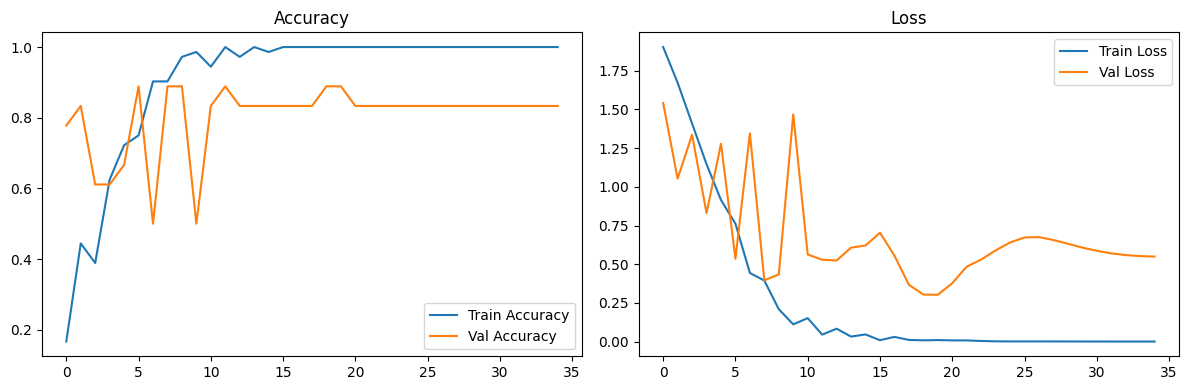

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.6667 - loss: 1.1410

Test Accuracy: 0.6667 | Test Loss: 1.1410


In [10]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred', label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

Task 6: Saving and reloading


In [11]:
model.save("fruit_cnn_model.h5")
print("Model saved!")

from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_cnn_model.h5")

loss, acc = loaded_model.evaluate(test_ds)
print(f"Reloaded Model — Test Accuracy: {acc:.4f}")

Model saved!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step - accuracy: 0.6667 - loss: 1.1410
Reloaded Model — Test Accuracy: 0.6667


Task 7: Prediction and Classification Report


In [12]:
import numpy as np
from sklearn.metrics import classification_report

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_dirs))

              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.62      1.00      0.77         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.71      1.00      0.83         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.67        30
   macro avg       0.75      0.67      0.63        30
weighted avg       0.75      0.67      0.63        30

